In [ ]:
%pip install spacy pandas torch transformers huggingface_hub matplotlib ipympl rdflib sentence_transformers numpy
# optuna and optional dependencies
%pip install optuna scikit-learn plotly 
# Qwen optimization (optional) dependencies
%pip install flash-linear-attention causal-conv1d
# Mistral dependencies
%pip install accelerate


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [60]:
import optuna
import optuna.visualization
import optuna.importance
from collections import OrderedDict
from mllms import (
    JSONTuplesPromptTemplate,
    JsonDictPromptTemplate,
    PromptTemplate,
    LLMAddressParsingModel,
    LlamaAddressParsingModel,
    QwenAddressParsingModel,
    MistralAddressParsingModel,
    DeepSeekAddressParsingModel,
    ZeroShot,
    SimilarExamples,
    FixedExamples,
    NERPatternSimilarExamples,
    FallbackExamplesStrategy,
    HybridSimilarExamples,
    FIXED_DEMO_EXAMPLES
)
from utils import compare_preds, format_time
from typing import NamedTuple
from optuna_utils import suggest_partial_permutation, suggest_permutation
import abc
import pandas as pd
import time
import pprint

OPTUNA_DB = "sqlite:///optuna_llms.db"
ESTIMATED_TOTAL_ADDRESSES = 4_228_682 # from compare.ipynb


In [61]:
import torch
available_accelerators = []
if torch.cuda.is_available():
    print("CUDA - available devices:")
    for current_trial in range(torch.cuda.device_count()):
        print(f"  {current_trial}: {torch.cuda.get_device_name(current_trial)}")
        available_accelerators.append(torch.device(f'cuda:{current_trial}'))
elif torch.accelerator.is_available(): # Support other hardware accelators
    available_accelerators.append(torch.accelerator.current_accelerator())
else:
    print("WARNING: Running on CPU")
    device = torch.device('cpu')

CUDA - available devices:
  0: NVIDIA A100 80GB PCIe
  1: NVIDIA A100 80GB PCIe


In [62]:
if available_accelerators:
    device = available_accelerators[1]
print(f"Torch version: {torch.__version__}, Device: {device}")

Torch version: 2.10.0+cu128, Device: cuda:1


In [63]:

ROLE_DESCRIPTIONS = OrderedDict([
    ("none", ""),
    (
        "german_archivist_ww2",
        "You are a German archivist handling the digitalization of German documents from "
        "the compensation efforts that followed the Second World War."
    ),
    (
        "archivist_ww2",
        "You are an archivist handling the digitalization of documents from "
        "the compensation efforts that followed the Second World War."
    ),
    (
        "german_archivist",
        "You are a German archivist handling the digitalization of German documents."
    ),
    (
        "archivist",
        "You are an archivist handling the digitalization of documents."
    )
])

TASK_DESCRIPTIONS = OrderedDict([
    ("simple", 
     "Annotate addresses, identifying the respective components of each address."),
    ("current_task", 
     "Your current task consists of annotating addresses "
     "identifying the respective components of each address."),
    ("archival_documents", 
     "Your current task consists of annotating addresses found in archival documents, "
     "identifying the respective components of each address.")
])

TASK_RESTRICTIONS = OrderedDict([
    (
        "loyal_to_text",
        "Remain loyal to the original text."
    ),
    (
        "explicitly_present_information", 
        "Only extract information **explicitly present in the address**."
    ),
    (
        "do_not_infer_missing_components",
        "Do **not infer missing components**."
    ),
    (
        "no_spelling_correction",
        "Do **not correct the spelling** of any word in the address."
    ),
    (
        "if_uncertain_exclude",
        "If uncertain about a component type, exclude it from the output."
    ),
    (
        "separate_neighborhood_and_city",
        "If the address contains a neighborhood joined together with a city "
        "by a dash (e.g., Berlin-Marienfelde), separate them accordingly."
    ),
    (
        "neighborhoods-not-cities",
        "Neighborhoods or boroughs should **not be classified as cities**."
    ),
    (
        "city-takes-precedence",
        "If unsure whether the city name in the address corresponds to the city or to a district, classify it as a city."
    ),
    (
        "district-not-city",
        "If the address contains a clearly identified district "
        "(such as by using the word \"Kreis\") **do not classify it as a city**."
    ),
    (
        "do-not-extract-keywords",
        "Do not extract keywords that identify a component type such "
        "as \"Kreis\", \"Nr.\" or \"Apt.\". "
        "The exception is streets and cities, which typically include "
        "such keywords as part of their name"
    ),
    (
        "do-not-extract-punctuation",
        "Do not extract punctuation around the words such as commas or dashes. "
        "The exception is when the word ends in a period to mark it as an abbreviation"
    ),
    (
        "concentration_camps",
        "Sometimes fields will mention concentration camps. "
        "The names of concentration camps should not be marked as any component."
    ),
    (
        "special_values",
        "Sometimes fields would be used to mark special cases "
        "when an address could not provided, such as when the person is missing. "
        "Do not classify such values as any component."
    ),
    (
        "disambiguation",
        "Sometimes cities will include (often connected by a slash \"/\") a reference to a nearby place (eg. river, city, district or region) "
        "for the purpose of disambiguation. "
        "If this is commonly part of the city name (eg. Frankfurt am Main), "
        "include it as part of the city component. "
        "Otherwise, it it fits another component type, classify it as such. "
        "Finally, if it does not fit any component type include it in the city name anyway."
    )
])

TASK_HINTS = OrderedDict([
    (
        "german_names", 
        "Addresses will often be written in German, meaning country and city names may be in German "
        "rather than the international standard."
    ),
    (
        "hebrew",
        "Addresses in Israel will often have words in Hebrew."
    ),
    (
        "german_phonetic_interpretation",
        "It is likely that the address was written down by a German person "
        "who might have interpreted the phonetics of the words differently. "
        "Therefore, \"J\" might take the place of an \"I\" sound, "
        "\"W\" might take the place of a \"V\" sound, etc."
    ),
    (
        "historical_names",
        "Some addresses might contain historical names of cities, "
        "streets or countries that no longer exist or have changed name."
    ),
    (
        "country_transitions",
        "Some addresses might contain cities that have transitioned to another country since "
        "the filling of the card."
    ),
    (
        "cardinal_direction_streets",
        "Streets in some countries are identified by their cardinal direction and a number, "
        "such as \"West 5th Avenue\"."
    ),
    (
        "abbreviations",
        "Place names in the addresses might be abbreviated."
    ),
    (
        "card_layout_kreis",
        "In some cards, the district keyword (Kreis) is part of the card layout. "
        "You may therefore encounter odd names with that keyword, such as country names."
    )
])

EXAMPLE_TERMS = OrderedDict([
    (
        "burg", 
        "\"burg\" for city"
    ),
    (
        "stadt",
        "\"stadt\" for city"
    ),
    (
        "kreis",
        "\"Kreis\" or its abbreviations \"Krs.\" or \"Kr.\" for district"
    ),
    (
        "regierungsbezirk",
        "\"Regierungsbezirk\" or its abbreviations \"Reg. Bez.\" for district"
    ),
    (
        "straße",
        "\"straße\" or its abbreviation \"str.\" for street"
    ),
    (
        "rechov",
        "\"rechov\" or its abbreviation \"rh.\" for street in Hebrew"
    ),
    (
        "avenue",
        "\"avenue\" or its abbreviation \"ave.\" for street"
    )
])

OUTPUT_FORMATS = OrderedDict([
    ("json_object", (
        "Format the output as a JSON object with the component types as keys.",
        JsonDictPromptTemplate
        )
    ),
    ("json_tuples", (
        "Format the output as a JSON list of [component, type] tuples.",
        JSONTuplesPromptTemplate
        )
    )
])

ENTITIES = [
    "HouseNumber",
    "StreetName",
    "Neighborhood",
    "City",
    "District",
    "State",
    "Region",
    "Country",
    "Other"
]

REQUIRED_ENTITIES = [
    "HouseNumber",
    "StreetName",
    "City",
    "Country"
]

OPTIONAL_ENTITIES = [entity for entity in ENTITIES if entity not in REQUIRED_ENTITIES]

PROMPT_SECTIONS = [
    "restrictions",
    "hints",
    "example_terms"
]

class PromptBuilder(abc.ABC):
    def __init__(
            self,
            role_description, 
            task_description,
            section_order,
            entities, 
            restrictions, 
            hints, 
            example_terms,
            terms_may_be_suffix,
            output_format
        ):
        self.role_description = role_description
        self.task_description = task_description
        self.section_order = section_order
        self.entities = entities
        self.restrictions = restrictions
        self.hints = hints
        self.example_terms = example_terms
        self.terms_may_be_suffix = terms_may_be_suffix
        self.output_format = output_format
        self.build_buffer : list[str] = []

    @abc.abstractmethod
    def _append_restrictions(self):
        raise NotImplementedError()
    
    @abc.abstractmethod
    def _append_hints(self):
        raise NotImplementedError()
    
    @abc.abstractmethod
    def _append_example_terms(self):
        raise NotImplementedError()

    def _append_item_list(self, keys : list[str], dictionary : dict[str, str]):
        for key in keys:
            self.build_buffer.append("- " + dictionary[key] + "\n")
    
    def _append_sections(self):
        for section in PROMPT_SECTIONS:
            if section not in self.section_order:
                raise ValueError(f"Section order must include all sections. Missing {section}.")
        for section in self.section_order:
            if section == "restrictions" and self.restrictions:
                self._append_restrictions()
            elif section == "hints" and self.hints:
                self._append_hints()
            elif section == "example_terms" and self.example_terms:
                self._append_example_terms()
            elif section not in PROMPT_SECTIONS:
                raise ValueError(f"Unknown section {section}.")

    @abc.abstractmethod
    def build(self) -> PromptTemplate:
        raise NotImplementedError()

class MarkdownPromptBuilder(PromptBuilder):
    def _append_restrictions(self):
        self.build_buffer.append("## Rules:\n\n")
        self._append_item_list(self.restrictions, TASK_RESTRICTIONS)
        self.build_buffer.append("\n")

    def _append_hints(self):
        self.build_buffer.append("## Hints:\n\n")
        self.build_buffer.append("When interpreting the addresses, take into consideration:\n")
        self._append_item_list(self.hints, TASK_HINTS)
        self.build_buffer.append("\n")

    def _append_example_terms(self):
        self.build_buffer.append("## Example Terms:\n\n")
        self.build_buffer.append("The addresses often include terms such as:\n")
        self._append_item_list(self.example_terms, EXAMPLE_TERMS)
        if self.terms_may_be_suffix:
            self.build_buffer.append("Some of these terms may occur as a suffix to another word.\n")
        self.build_buffer.append("\n")

    def build(self) -> PromptTemplate:
        self.build_buffer = []
        if self.role_description != "none":
            self.build_buffer.append("# Role\n\n")
            self.build_buffer.append(ROLE_DESCRIPTIONS[self.role_description])
            self.build_buffer.append("\n\n")
        self.build_buffer.append("# Task\n\n")
        self.build_buffer.append(TASK_DESCRIPTIONS[self.task_description])
        self.build_buffer.append(" Consider the component types: ")
        self.build_buffer.append(", ".join(self.entities))
        self.build_buffer.append(".\n\n")
        self._append_sections()
        self.build_buffer.append(OUTPUT_FORMATS[self.output_format][0])
        self.build_buffer.append("\n")
        self.build_buffer.append("%(examples)s\n")
        self.build_buffer.append("Now annotate the following address:\n%(address)s")
        prompt_template = "".join(self.build_buffer)
        example_prefix = "# Examples\n\n"
        prompt_class = OUTPUT_FORMATS[self.output_format][1]
        return prompt_class(
            template=prompt_template,
            examples_prefix=example_prefix
        )

class PlainPromptBuilder(PromptBuilder):
    def _append_restrictions(self):
        self.build_buffer.append("It is essential that while solving the task you stick to the following rules:\n")
        self._append_item_list(self.restrictions, TASK_RESTRICTIONS)
        self.build_buffer.append("\n")

    def _append_hints(self):
        self.build_buffer.append("When interpreting the addresses, take into consideration:\n")
        self._append_item_list(self.hints, TASK_HINTS)
        self.build_buffer.append("\n")

    def _append_example_terms(self):
        self.build_buffer.append("The addresses often include terms such as:\n")
        self._append_item_list(self.example_terms, EXAMPLE_TERMS)
        if self.terms_may_be_suffix:
            self.build_buffer.append("Some of these terms may occur as a suffix to another word.\n")
        self.build_buffer.append("\n")

    def build(self) -> PromptTemplate:
        self.build_buffer = []
        if self.role_description != "none":
            self.build_buffer.append(ROLE_DESCRIPTIONS[self.role_description])
            self.build_buffer.append(" ")
        self.build_buffer.append(TASK_DESCRIPTIONS[self.task_description])
        self.build_buffer.append(" Consider the component types: ")
        self.build_buffer.append(", ".join(self.entities))
        self.build_buffer.append(".\n\n")
        self._append_sections()
        self.build_buffer.append(OUTPUT_FORMATS[self.output_format][0])
        self.build_buffer.append("\n")
        self.build_buffer.append("%(examples)s\n")
        self.build_buffer.append("Now annotate the following address:\n%(address)s")
        prompt_template = "".join(self.build_buffer)
        example_prefix = "Consider the following examples:\n"
        prompt_class = OUTPUT_FORMATS[self.output_format][1]
        return prompt_class(
            template=prompt_template,
            examples_prefix=example_prefix
        )
    
PROMPT_FORMATS = OrderedDict([
    ("plain", PlainPromptBuilder),
    ("markdown", MarkdownPromptBuilder)
])

def suggest_prompt(trial : optuna.Trial, entities_to_predict) -> PromptTemplate:
    prompt_format = trial.suggest_categorical("prompt_format", ["plain", "markdown"])
    role_description = trial.suggest_categorical("prompt_role_description", list(ROLE_DESCRIPTIONS.keys()))
    task_description = trial.suggest_categorical("prompt_task_description", list(TASK_DESCRIPTIONS.keys()))
    restrictions = suggest_partial_permutation(trial, "prompt_restrictions", list(TASK_RESTRICTIONS.keys()))
    hints = suggest_partial_permutation(trial, "prompt_hints", list(TASK_HINTS.keys()))
    example_terms = suggest_partial_permutation(trial, "prompt_example_terms", list(EXAMPLE_TERMS.keys()))
    section_order = suggest_permutation(trial, "prompt_section_order", PROMPT_SECTIONS)
    if len(example_terms) > 0:
        terms_may_be_suffix = trial.suggest_categorical("prompt_example_terms_may_be_suffix", [True, False])
    else: terms_may_be_suffix = False
    output_format = trial.suggest_categorical("output_format", list(OUTPUT_FORMATS.keys()))
    prompt_builder = PROMPT_FORMATS[prompt_format](
        role_description, task_description, section_order, entities_to_predict, restrictions,
        hints, example_terms, terms_may_be_suffix, output_format
    )
    return prompt_builder.build()

In [64]:
def get_random_prompts(n = 1, seed=None):
    sampler = optuna.samplers.RandomSampler(seed)
    study = optuna.create_study(sampler=sampler)
    return [
        suggest_prompt(study.ask(), ENTITIES) for _ in range(n)
    ]

for current_trial, prompt in enumerate(get_random_prompts(n=20)):
    print(f"Prompt {current_trial}")
    print(prompt.template)
    print("\n")

[I 2026-03-23 13:01:06,230] A new study created in memory with name: no-name-b0ad42e7-2610-4977-b498-969bed3f37af


Prompt 0
Your current task consists of annotating addresses found in archival documents, identifying the respective components of each address. Consider the component types: HouseNumber, StreetName, Neighborhood, City, District, State, Region, Country, Other.

It is essential that while solving the task you stick to the following rules:
- Do not extract keywords that identify a component type such as "Kreis", "Nr." or "Apt.". The exception is streets and cities, which typically include such keywords as part of their name
- If the address contains a neighborhood joined together with a city by a dash (e.g., Berlin-Marienfelde), separate them accordingly.
- Do not extract punctuation around the words such as commas or dashes. The exception is when the word ends in a period to mark it as an abbreviation
- Neighborhoods or boroughs should **not be classified as cities**.
- If the address contains a clearly identified district (such as by using the word "Kreis") **do not classify it as a cit

In [65]:
csv_read_args = dict(keep_default_na=False, dtype=str, na_values=[""])

bzkopen_train = pd.read_csv("open_data/bzkopen_addresses_train.csv", **csv_read_args)
bzkopen_val = pd.read_csv("open_data/bzkopen_addresses_val.csv", **csv_read_args)
bzkopen_test = pd.read_csv("open_data/bzkopen_addresses_test.csv", **csv_read_args)

In [66]:
def suggest_example_strategy(trial : optuna.Trial, entities_to_predict):
    example_strategy = trial.suggest_categorical("example_strategy", [
        "zero_shot",
        "similar_semantic_embeddings",
        "fixed_examples",
        "ner_pattern_matching",
        "hybrid_embeddings_ner",
        #"embeddings_fallback_fixed"
    ])
    def suggest_nshots():
        return trial.suggest_int("number_of_examples", 0, 15)

    def suggest_cosine_similarity_threshold():
        return trial.suggest_float("similar_semantic_embeddings_threshold", -1.0, 1.0, step=0.05)
    
    def suggest_embedding_model():
        return trial.suggest_categorical("similar_semantic_embeddings_embedding_model", [
            "multi-qa-mpnet-base-dot-v1",
            "all-MiniLM-L6-v2",
            "multi-qa-distilbert-cos-v1"
        ])
    
    def suggest_fixed_examples():
        example_keys = [str(i) for i in range(len(FIXED_DEMO_EXAMPLES))]
        example_keys = suggest_partial_permutation(trial, "fixed_examples", example_keys)
        return [FIXED_DEMO_EXAMPLES[int(key)] for key in example_keys]
        
    if example_strategy == "zero_shot":
        trial.set_user_attr("number_of_examples", 0)
        return ZeroShot()
    if example_strategy == "similar_semantic_embeddings":
        threshold = suggest_cosine_similarity_threshold()
        embedding_model = suggest_embedding_model()
        n_shots = suggest_nshots()
        trial.set_user_attr("number_of_examples", n_shots)
        return SimilarExamples(
            num_examples=n_shots,
            similarity_threshold=threshold,
            embedding_model=embedding_model,
            example_addresses=bzkopen_train["FullAddress"],
            example_labels=bzkopen_train,
            labels_to_include=entities_to_predict
        )
    elif example_strategy == "fixed_examples":
        fixed_examples = suggest_fixed_examples()
        trial.set_user_attr("number_of_examples", len(fixed_examples))
        return FixedExamples(fixed_examples, labels_to_include=entities_to_predict)
    elif example_strategy == "ner_pattern_matching":
        n_shots = suggest_nshots()
        trial.set_user_attr("number_of_examples", n_shots)
        return NERPatternSimilarExamples(
            example_addresses=bzkopen_train["FullAddress"],
            example_labels=bzkopen_train,
            num_examples=n_shots,
            labels_to_include=entities_to_predict
        )
    elif example_strategy == "hybrid_embeddings_ner":
        threshold = suggest_cosine_similarity_threshold()
        embedding_model = suggest_embedding_model()
        n_shots = suggest_nshots()
        trial.set_user_attr("number_of_examples", n_shots)
        return HybridSimilarExamples(
            embedding_strategy=SimilarExamples(
                num_examples=n_shots,
                similarity_threshold=threshold,
                embedding_model=embedding_model,
                example_addresses=bzkopen_train["FullAddress"],
                example_labels=bzkopen_train,
                labels_to_include=entities_to_predict
            ),
            pattern_strategy=NERPatternSimilarExamples(
                example_addresses=bzkopen_train["FullAddress"],
                example_labels=bzkopen_train,
                num_examples=n_shots,
                labels_to_include=entities_to_predict
            ),
            num_examples=n_shots,
            pool_size=n_shots
        )
    # TODO why exclude all embedding retrieved examples based on average instead of each example individually?
    #elif example_strategy == "embeddings_fallback_fixed":
    #    threshold = suggest_cosine_similarity_threshold()
    #    embedding_model = suggest_embedding_model()
    #    n_shots = suggest_nshots()
    #    fixed_examples = suggest_fixed_examples()
    #    trial.set_user_attr("number_of_examples", n_shots)
    #    return FallbackExamplesStrategy(
    #        primary_strategy=SimilarExamples(
    #            num_examples=n_shots,
    #            embedding_model=embedding_model,
    #            example_addresses=bzkopen_train["FullAddress"],
    #            example_labels=bzkopen_train,
    #            labels_to_include=entities_to_predict
    #        ),
    #        labels_to_include=entities_to_predict,
    #        demo_examples=fixed_examples
    #    )
    else:
        raise NotImplementedError(f"Example strategy {example_strategy} not implemented.")


class ScoreTuple(NamedTuple):
    f1 : float
    precision : float
    country_city_f1 : float
    n_entities : int
    all_entities_f1 : float
    rate : float

DIRECTIONS = [
    "maximize",
    "maximize",
    "maximize",
    "maximize",
    "maximize",
    "maximize"
]

class LLMModelObjective:
    def __init__(self, model_names : str | list[str], model_class, study_name : str = None):
        if isinstance(model_names, str):
            model_names = [model_names]
        self.model_names = model_names
        self.model_class = model_class
        self.study_name = study_name or model_names[0]

    def __call__(self, trial : optuna.Trial):
        entities = suggest_partial_permutation(trial, "prompt_extra_entities", OPTIONAL_ENTITIES)
        entities = REQUIRED_ENTITIES + entities
        entities = [entity for entity in ENTITIES if entity in entities] # Recover original order
        entities_except_other = [entity for entity in entities if entity != "Other"]
        prompt = suggest_prompt(trial, entities)
        if len(self.model_names) == 1:
            model_name = self.model_names[0]
        else:
            model_name = trial.suggest_categorical("model", self.model_names)
        trial.set_user_attr("entities", entities)
        trial.set_user_attr("n_entities", len(entities))
        trial.set_user_attr("prompt_template", prompt.template)
        trial.set_user_attr("prompt_class", prompt.__class__.__name__)
        example_strategy = suggest_example_strategy(trial, entities_except_other)
        model = self.model_class(
            model_name=model_name,
            prompt=prompt,
            example_strategy=example_strategy,
            device=device
        )
        start = time.monotonic()
        preds = model.parse_addresses(bzkopen_val["FullAddress"])
        end = time.monotonic()
        preds = pd.DataFrame(preds)
        results = {}
        results["required"] = compare_preds(preds=preds, labels=bzkopen_val, target_columns=REQUIRED_ENTITIES)
        results["country_city"] = compare_preds(preds=preds, labels=bzkopen_val, target_columns=["City", "Country"])
        results["all_entities"] = compare_preds(preds=preds, labels=bzkopen_val, target_columns=entities_except_other)
        
        for key, subdict in results.items():
            for metric, value in subdict.items():
                trial.set_user_attr(f"{key}_{metric}", value)

        deltatime = end - start
        rate = len(bzkopen_val) / deltatime
        trial.set_user_attr("deltatime", deltatime)
        trial.set_user_attr("rate", rate)
        trial.set_user_attr("estimated_total_time", format_time(ESTIMATED_TOTAL_ADDRESSES / rate))
        

        errors = int(preds["error"].notna().sum()) if "error" in preds.columns else 0
        trial.set_user_attr("errors", errors)
        trial.set_user_attr("error_rate", errors / len(preds))
        

        return ScoreTuple(
            f1=results["required"]["f1"], 
            precision=results["required"]["precision"], 
            country_city_f1=results["country_city"]["f1"],
            n_entities=len(entities),
            all_entities_f1=results["all_entities"]["f1"],
            rate=rate
        )




In [67]:

def print_trial_info(study : optuna.Study, trial : optuna.Trial):
    print(f"Trial {trial.number}")
    pprint.pprint(ScoreTuple(*trial.values)._asdict(), sort_dicts=False)
    print("Params:")
    pprint.pprint(trial.params)
    user_attrs = trial.user_attrs.copy()
    prompt_template = user_attrs.pop("prompt_template")
    print(f"User attrs:")
    pprint.pprint(user_attrs)
    print(f"Prompt template:\n{prompt_template}\n")


def run_study_up_to(study : optuna.Study, objective, stop_trial : int, **kwargs):
    n_trials_to_run = stop_trial - len(study.trials)
    # default args:
    kwargs["gc_after_trial"] = kwargs.get("gc_after_trial", True)
    kwargs["callbacks"] = kwargs.get("callbacks", [print_trial_info])
    if n_trials_to_run > 0:
        study.optimize(objective, n_trials=n_trials_to_run, **kwargs)
    else:
        print(f"Study already has {len(study.trials)} trials, which is greater than or equal to the requested {stop_trial} trials. No optimization will be run.")

models_to_study = [
    LLMModelObjective("Qwen/Qwen3.5-9B", 
                      QwenAddressParsingModel, study_name="Qwen3.5-9B"),
    LLMModelObjective("meta-llama/Meta-Llama-3-8B-Instruct", 
                      LlamaAddressParsingModel, study_name="Llama-3-8B"),
    LLMModelObjective("mistralai/Ministral-3-8B-Instruct-2512", 
                      MistralAddressParsingModel, study_name="Mistral-3-8B-Instruct"),
    LLMModelObjective("mistralai/Ministral-3-8B-Reasoning-2512", 
                      MistralAddressParsingModel, study_name="Mistral-3-8B-Reasoning"),
    LLMModelObjective("deepseek-ai/DeepSeek-R1-Distill-Llama-8B",
                      DeepSeekAddressParsingModel, study_name="DeepSeek-R1-Llama-8B"),
    LLMModelObjective("deepseek-ai/DeepSeek-R1-0528-Qwen3-8B",
                      DeepSeekAddressParsingModel, study_name="DeepSeek-R1-Qwen3-8B")
                      
]

studies = [
    optuna.create_study(
        storage = OPTUNA_DB,
        study_name=model.study_name,
        load_if_exists=True,
        directions=DIRECTIONS
    ) for model in models_to_study
]

def run_all_up_to(studies, models_to_study, n_trials = 100, rotate = 50, **kwargs):
    current_trial = 0
    while current_trial < n_trials:
        next_trial = n_trials if rotate is None else min(current_trial + rotate, n_trials)
        for study, model in zip(studies, models_to_study):
            print(f"Running study {study.study_name} up to trial {next_trial}")
            run_study_up_to(study, model, stop_trial=next_trial, **kwargs)
        current_trial = next_trial
    print("\nAll studies completed.\n")
    for study in studies:
        best_trials = study.best_trials.copy()
        best_trials.sort(key=lambda trial: trial.values, reverse=True)
        if best_trials:
            print(f"Best trials for study {study.study_name}:")
            for best_trial in best_trials:
                print_trial_info(study, best_trial)
        else:
            print(f"No trials found for study {study.study_name}.")
        print("\n\n")



[I 2026-03-23 13:01:06,356] Using an existing study with name 'Qwen3.5-9B' instead of creating a new one.


[I 2026-03-23 13:01:06,380] Using an existing study with name 'Llama-3-8B' instead of creating a new one.
[I 2026-03-23 13:01:06,403] Using an existing study with name 'Mistral-3-8B-Instruct' instead of creating a new one.
[I 2026-03-23 13:01:06,423] Using an existing study with name 'Mistral-3-8B-Reasoning' instead of creating a new one.
[I 2026-03-23 13:01:06,445] Using an existing study with name 'DeepSeek-R1-Llama-8B' instead of creating a new one.
[I 2026-03-23 13:01:06,465] Using an existing study with name 'DeepSeek-R1-Qwen3-8B' instead of creating a new one.


In [68]:
#Run each model once to make sure everything is set up correctly
run_all_up_to(studies, models_to_study, n_trials=1)

Running study Qwen3.5-9B up to trial 1
Study already has 100 trials, which is greater than or equal to the requested 1 trials. No optimization will be run.
Running study Llama-3-8B up to trial 1
Study already has 100 trials, which is greater than or equal to the requested 1 trials. No optimization will be run.
Running study Mistral-3-8B-Instruct up to trial 1
Study already has 100 trials, which is greater than or equal to the requested 1 trials. No optimization will be run.
Running study Mistral-3-8B-Reasoning up to trial 1
Study already has 10 trials, which is greater than or equal to the requested 1 trials. No optimization will be run.
Running study DeepSeek-R1-Llama-8B up to trial 1
Study already has 10 trials, which is greater than or equal to the requested 1 trials. No optimization will be run.
Running study DeepSeek-R1-Qwen3-8B up to trial 1
Study already has 10 trials, which is greater than or equal to the requested 1 trials. No optimization will be run.

All studies completed.


In [69]:
# Run all studies up to 10 trials to get a sense of expectable performance and time requirements
run_all_up_to(studies, models_to_study, n_trials=10, rotate=1)

Running study Qwen3.5-9B up to trial 1


Study already has 100 trials, which is greater than or equal to the requested 1 trials. No optimization will be run.
Running study Llama-3-8B up to trial 1
Study already has 100 trials, which is greater than or equal to the requested 1 trials. No optimization will be run.
Running study Mistral-3-8B-Instruct up to trial 1
Study already has 100 trials, which is greater than or equal to the requested 1 trials. No optimization will be run.
Running study Mistral-3-8B-Reasoning up to trial 1
Study already has 10 trials, which is greater than or equal to the requested 1 trials. No optimization will be run.
Running study DeepSeek-R1-Llama-8B up to trial 1
Study already has 10 trials, which is greater than or equal to the requested 1 trials. No optimization will be run.
Running study DeepSeek-R1-Qwen3-8B up to trial 1
Study already has 10 trials, which is greater than or equal to the requested 1 trials. No optimization will be run.
Running study Qwen3.5-9B up to trial 2
Study already has 100 tr

In [70]:
def get_top_studies(studies, models_to_study, top_k=3):
    # Select the best 3 studies and models to run up to 100 trials
    studies_scored = [
        (
            study,
            objective,
            max(trial.values for trial in study.best_trials)
        ) for study, objective in zip(studies, models_to_study) if study.best_trials
    ]

    studies_scored.sort(key=lambda x: tuple(x[2]), reverse=True) # Sort by score tuple in descending order
    top_study_tuples = studies_scored[:top_k]
    top_studies = [tup[0] for tup in top_study_tuples]
    top_objectives = [tup[1] for tup in top_study_tuples]

    print("Best studies:")
    for study in top_studies:
        print(f"Study {study.study_name} - Number of trials: {len(study.trials)}")
        best_trial = max(study.best_trials, key=lambda trial: tuple(trial.values))
        print_trial_info(study, best_trial)
        print("\n\n")
    return top_studies, top_objectives
top_studies, top_objectives = get_top_studies(studies, models_to_study, top_k=3)


Best studies:
Study Qwen3.5-9B - Number of trials: 100
Trial 38
{'f1': 0.912,
 'precision': 0.9076433121019108,
 'country_city_f1': 0.9287598944591028,
 'n_entities': 6.0,
 'all_entities_f1': 0.8892215568862275,
 'rate': 4.170326593219914}
Params:
{'example_strategy': 'hybrid_embeddings_ner',
 'number_of_examples': 15,
 'output_format': 'json_object',
 'prompt_example_terms_avenue_include': False,
 'prompt_example_terms_burg_include': False,
 'prompt_example_terms_kreis_include': False,
 'prompt_example_terms_may_be_suffix': True,
 'prompt_example_terms_rechov_include': False,
 'prompt_example_terms_regierungsbezirk_include': False,
 'prompt_example_terms_stadt_include': False,
 'prompt_example_terms_straße_include': True,
 'prompt_extra_entities_District_include': False,
 'prompt_extra_entities_Neighborhood_include': True,
 'prompt_extra_entities_Neighborhood_sortkey': 0,
 'prompt_extra_entities_Other_include': True,
 'prompt_extra_entities_Region_include': False,
 'prompt_extra_entit

In [71]:
run_all_up_to(top_studies, top_objectives, n_trials=100)

Running study Qwen3.5-9B up to trial 50
Study already has 100 trials, which is greater than or equal to the requested 50 trials. No optimization will be run.
Running study Mistral-3-8B-Instruct up to trial 50
Study already has 100 trials, which is greater than or equal to the requested 50 trials. No optimization will be run.
Running study Llama-3-8B up to trial 50
Study already has 100 trials, which is greater than or equal to the requested 50 trials. No optimization will be run.
Running study Qwen3.5-9B up to trial 100
Study already has 100 trials, which is greater than or equal to the requested 100 trials. No optimization will be run.
Running study Mistral-3-8B-Instruct up to trial 100
Study already has 100 trials, which is greater than or equal to the requested 100 trials. No optimization will be run.
Running study Llama-3-8B up to trial 100
Study already has 100 trials, which is greater than or equal to the requested 100 trials. No optimization will be run.

All studies completed.


In [127]:
def param_box_plot(study_df : pd.DataFrame, *, target = ("values", 0), param_name : str | None = None, user_attr : str | None = None):
    assert (param_name is not None) != (user_attr is not None), "Exactly one of param_name or user_attr must be provided."
    df = study_df
    df = df[df["state"] == "COMPLETE"]
    col_type = "params" if param_name is not None else "user_attrs"
    col_name = param_name if param_name is not None else user_attr
    df = df[df[(col_type, col_name)].notna()]
    df = df[[target, (col_type, col_name)]].pivot(columns=[(col_type, col_name)], values=target)
    return df.plot.box(
        title=f"Distribution of objective value by {col_name}",
        vert=False,
        grid=True
    )

def param_scatter_plot(study_df : pd.DataFrame, *, target = ("values", 0), param_name : str | None = None, user_attr : str | None = None):
    assert (param_name is not None) != (user_attr is not None), "Exactly one of param_name or user_attr must be provided."
    df = study_df
    df = df[df["state"] == "COMPLETE"]
    col_type = "params" if param_name is not None else "user_attrs"
    col_name = param_name if param_name is not None else user_attr
    df = df[df[(col_type, col_name)].notna()]
    return df.plot.scatter(
        x=(col_type, col_name),
        y=target,
        title=f"Distribution of objective value by {col_name}"
    )

def param_list_box_plot(study_df : pd.DataFrame, list_key : str, *, target = ("values", 0)):
    list_include_params = [
        param for param in study_df.columns 
        if param[0] == "params" and param[1].startswith(list_key + "_") and param[1].endswith("_include")
    ]
    df = study_df[study_df["state"] == "COMPLETE"]
    selected = OrderedDict()

    for col in list_include_params:
        mask = df[col].eq(True)
        if mask.any():
            name = col[1][len(list_key) + 1 : -len("_include")]
            selected[name] = df.loc[mask, target].reset_index(drop=True)
            selected["no " + name] = df.loc[~mask, target].reset_index(drop=True)
    if not selected:
        raise ValueError(f"No trials found with any '{list_key}_*_include' set to True.")

    plot_df = pd.DataFrame(selected)
    return plot_df.plot.box(
        title=f"Distribution of objective value by {list_key} items (include=True)",
        vert=False,
        grid=True
    )

top_studies, top_objectives = get_top_studies(studies, models_to_study, top_k=3)


Best studies:
Study Qwen3.5-9B - Number of trials: 100
Trial 38
{'f1': 0.912,
 'precision': 0.9076433121019108,
 'country_city_f1': 0.9287598944591028,
 'n_entities': 6.0,
 'all_entities_f1': 0.8892215568862275,
 'rate': 4.170326593219914}
Params:
{'example_strategy': 'hybrid_embeddings_ner',
 'number_of_examples': 15,
 'output_format': 'json_object',
 'prompt_example_terms_avenue_include': False,
 'prompt_example_terms_burg_include': False,
 'prompt_example_terms_kreis_include': False,
 'prompt_example_terms_may_be_suffix': True,
 'prompt_example_terms_rechov_include': False,
 'prompt_example_terms_regierungsbezirk_include': False,
 'prompt_example_terms_stadt_include': False,
 'prompt_example_terms_straße_include': True,
 'prompt_extra_entities_District_include': False,
 'prompt_extra_entities_Neighborhood_include': True,
 'prompt_extra_entities_Neighborhood_sortkey': 0,
 'prompt_extra_entities_Other_include': True,
 'prompt_extra_entities_Region_include': False,
 'prompt_extra_entit

None

None

None

None

None

None

None

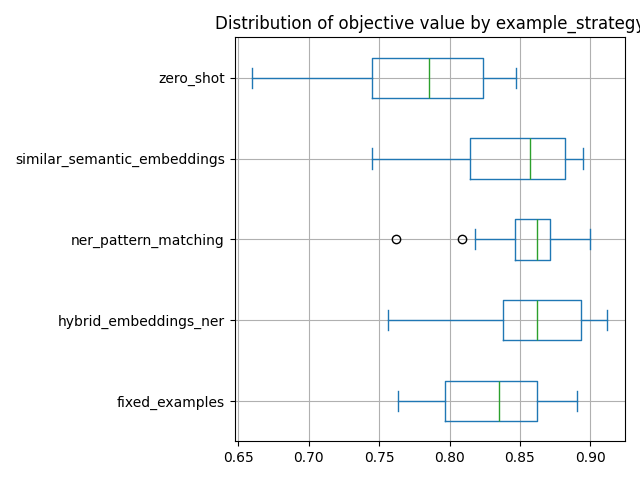

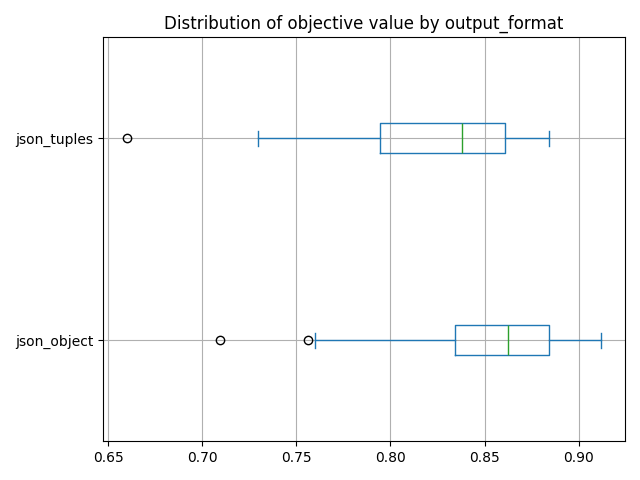

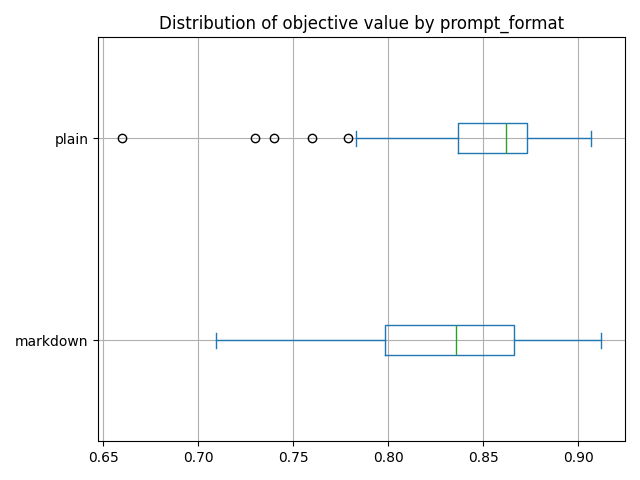

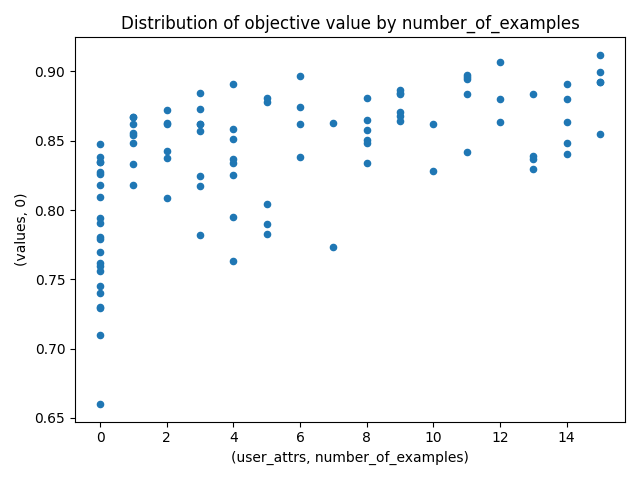

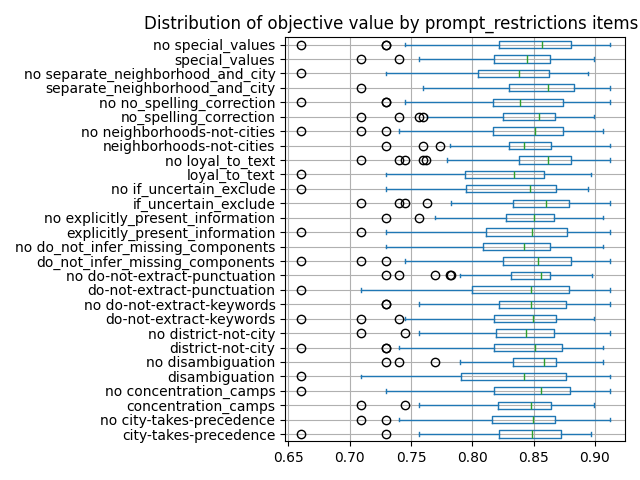

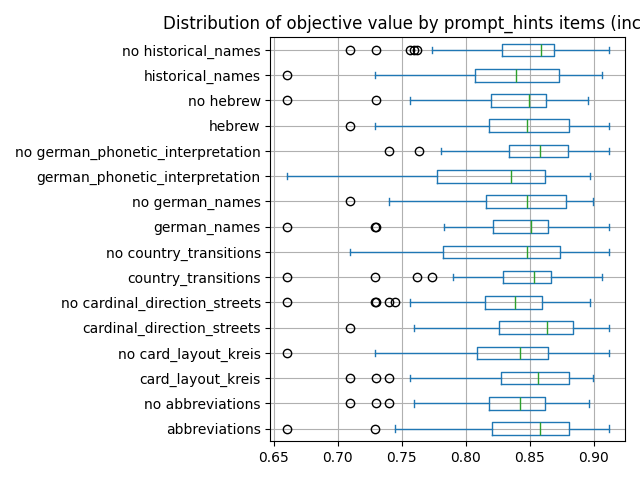

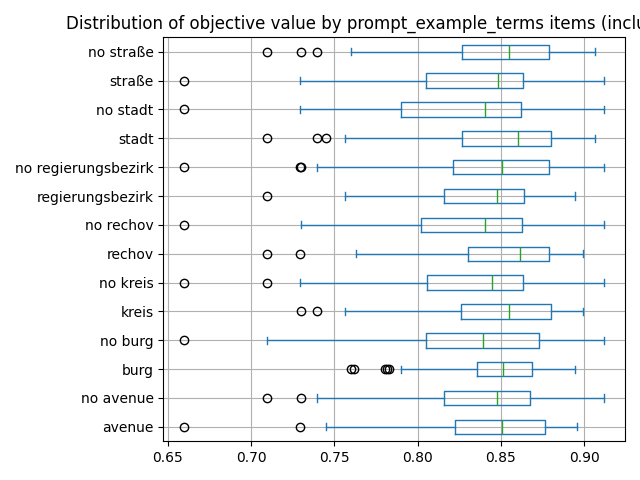

In [128]:

top_study = top_studies[0]
study_df = top_study.trials_dataframe(multi_index=True)
%matplotlib widget
display(param_box_plot(study_df, param_name="example_strategy").figure.tight_layout())
display(param_box_plot(study_df, param_name="output_format").figure.tight_layout())
display(param_box_plot(study_df, param_name="prompt_format").figure.tight_layout())
display(param_scatter_plot(study_df, user_attr="number_of_examples").figure.tight_layout())
display(param_list_box_plot(study_df, list_key="prompt_restrictions").figure.tight_layout())
display(param_list_box_plot(study_df, list_key="prompt_hints").figure.tight_layout())
display(param_list_box_plot(study_df, list_key="prompt_example_terms").figure.tight_layout())